# Quantum Orthogonal Neural Network Training on COCO Dataset

This notebook demonstrates training a quantum orthogonal neural network with statistical pruning on the COCO dataset. The model uses a hybrid quantum-classical architecture with scheduled gradient pruning.

In [7]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # Silence INFO and WARNING messages
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import tensorflow as tf
import pennylane as qml
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Import our custom model and utilities
import sys
sys.path.append('../src')
from models.orthogonal_nn import HybridModel
from utils.rbs_gate import *
from utils.pruning import ScheduledGradientPruning

## 1. Data Loading and Preprocessing

First, we'll load and preprocess the COCO dataset. We'll focus on a subset of the dataset for demonstration purposes.

In [8]:
def load_coco_data(data_dir='../data/test2017', num_samples=1000, img_size=(32, 32)):
    """Load and preprocess COCO dataset.
    
    Args:
        data_dir: Directory containing COCO images
        num_samples: Number of samples to load
        img_size: Target image size
    """
    images = []
    labels = []
    
    # Get list of image files
    image_files = [f for f in os.listdir(data_dir) if f.endswith(('.jpg', '.png'))]
    image_files = image_files[:num_samples]
    
    for img_file in tqdm(image_files, desc='Loading images'):
        img_path = os.path.join(data_dir, img_file)
        # Read and preprocess image
        img = tf.keras.preprocessing.image.load_img(img_path, target_size=img_size)
        img_array = tf.keras.preprocessing.image.img_to_array(img)
        img_array = img_array / 255.0  # Normalize to [0,1]
        
        images.append(img_array)
        # For demonstration, we'll use a binary classification task
        # You can modify this based on your specific needs
        labels.append(np.random.randint(0, 2))
    
    return np.array(images), np.array(labels)

# Load the dataset
X, y = load_coco_data()

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create TensorFlow datasets
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train)).batch(128)
test_dataset = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(128)

Loading images:   2%|▏         | 15/1000 [00:00<00:06, 144.02it/s]

Loading images: 100%|██████████| 1000/1000 [00:06<00:00, 144.24it/s]


## 2. Model Configuration

Configure the quantum orthogonal neural network with statistical pruning.

In [9]:
# Model parameters
random_seed = 42
algorithm = 'pruning'
algorithm_params = {
    'accumulate_window': 100,  # Number of steps to accumulate gradients
    'prune_window': 200,       # Number of steps between pruning operations
    'prune_ratio': 0.5,        # Ratio of weights to prune
    'schedule': 'linear'       # Pruning schedule (linear, exponential, or step)
}

# Create and compile the model
model = HybridModel(
    random=random_seed,
    algorithm=algorithm,
    algorithm_params=algorithm_params,
    wires=6
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

## 3. Training Loop

Train the model with custom callbacks to monitor the pruning process.

In [13]:
class PruningCallback(tf.keras.callbacks.Callback):
    def __init__(self, model):
        super(PruningCallback, self).__init__()
        self.model = model
        self.pruning_history = []
    
    def on_epoch_end(self, epoch, logs=None):
        if hasattr(self.model, 'algorithm'):
            pruning_stats = self.model.algorithm.get_pruning_stats()
            self.pruning_history.append(pruning_stats)
            print(f"Epoch {epoch + 1}: Pruning ratio = {pruning_stats['current_ratio']:.3f}")

# Training parameters
epochs = 100
callbacks = [
    PruningCallback(model),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True
    )
]

# Train the model
history = model.fit(
    train_dataset,
    epochs=epochs,
    validation_data=test_dataset,
    callbacks=callbacks
)

Epoch 1/100


7/7 [==============================] - 5s 669ms/step - loss: 0.6871 - accuracy: 0.5425 - val_loss: 0.6945 - val_accuracy: 0.5050
Epoch 2/100
7/7 [==============================] - 5s 683ms/step - loss: 0.6790 - accuracy: 0.5713 - val_loss: 0.6995 - val_accuracy: 0.5200
Epoch 3/100
7/7 [==============================] - 5s 692ms/step - loss: 0.6718 - accuracy: 0.5913 - val_loss: 0.7118 - val_accuracy: 0.4800
Epoch 4/100
7/7 [==============================] - 5s 728ms/step - loss: 0.6688 - accuracy: 0.5825 - val_loss: 0.7216 - val_accuracy: 0.4750
Epoch 5/100
7/7 [==============================] - 5s 725ms/step - loss: 0.6671 - accuracy: 0.5713 - val_loss: 0.7143 - val_accuracy: 0.5000
Epoch 6/100
7/7 [==============================] - 5s 686ms/step - loss: 0.6519 - accuracy: 0.6150 - val_loss: 0.7234 - val_accuracy: 0.4650
Epoch 7/100
7/7 [==============================] - 5s 738ms/step - loss: 0.6358 - accuracy: 0.6488 - val_loss: 0.7232 - val_accuracy: 0.5050
Epoch 8/100
7/7 [========

## 4. Visualization and Analysis

Plot the training history and pruning statistics.

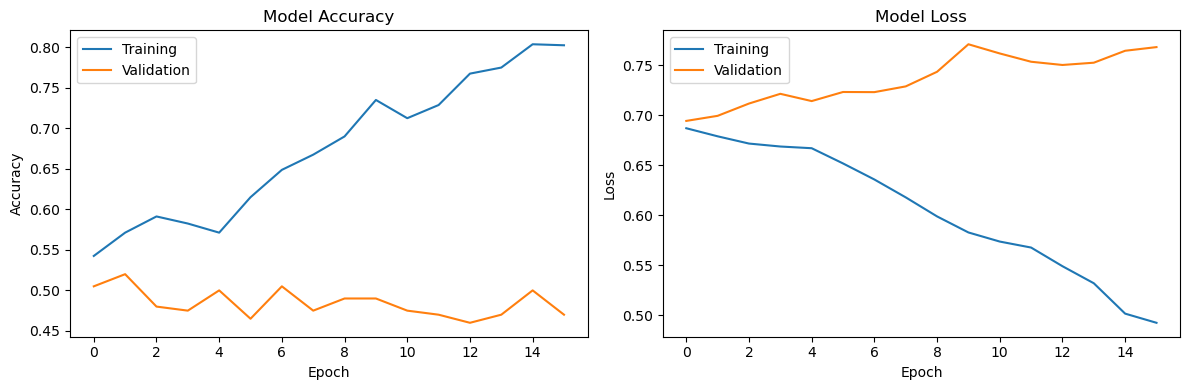

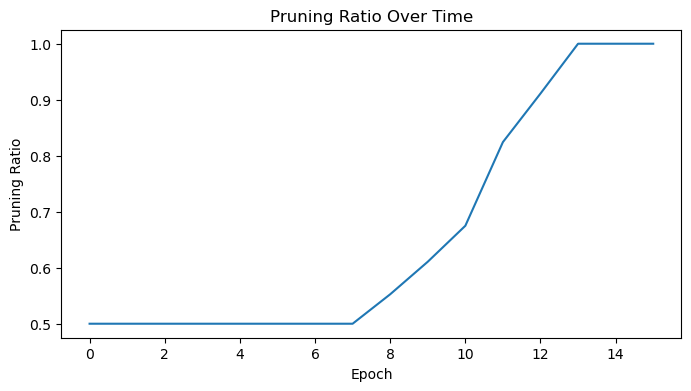

In [14]:
def plot_training_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    # Plot accuracy
    ax1.plot(history.history['accuracy'], label='Training')
    ax1.plot(history.history['val_accuracy'], label='Validation')
    ax1.set_title('Model Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    
    # Plot loss
    ax2.plot(history.history['loss'], label='Training')
    ax2.plot(history.history['val_loss'], label='Validation')
    ax2.set_title('Model Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    
    plt.tight_layout()
    plt.show()

def plot_pruning_history(callback):
    pruning_ratios = [stats['current_ratio'] for stats in callback.pruning_history]
    plt.figure(figsize=(8, 4))
    plt.plot(pruning_ratios)
    plt.title('Pruning Ratio Over Time')
    plt.xlabel('Epoch')
    plt.ylabel('Pruning Ratio')
    plt.show()

# Plot training history
plot_training_history(history)

# Plot pruning history
plot_pruning_history(callbacks[0])

## 5. Model Evaluation

Evaluate the model's performance on the test set.

In [12]:
# Evaluate the model
test_loss, test_accuracy = model.evaluate(test_dataset)
print(f"\nTest accuracy: {test_accuracy:.4f}")

# Get final pruning statistics
final_stats = callbacks[0].pruning_history[-1]
print(f"\nFinal pruning ratio: {final_stats['current_ratio']:.3f}")
print(f"Number of pruned weights: {final_stats['num_pruned']}")
print(f"Total weights: {final_stats['total_weights']}")

2/2 [==============================] - 0s 67ms/step - loss: 0.6926 - accuracy: 0.4950

Test accuracy: 0.4950

Final pruning ratio: 0.500
Number of pruned weights: 7
Total weights: 15
